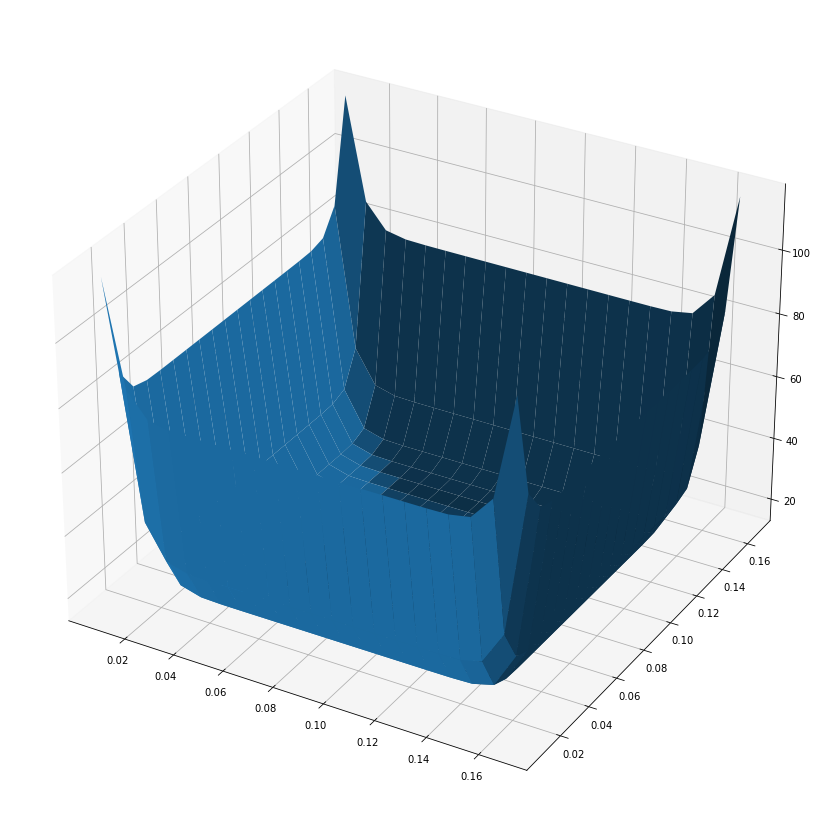

In [4]:
import numpy as np

# Oppsett av matrisen L
m=20                  
x=np.linspace(0,0.175,m+2)
h=x[1]-x[0]            
Ln = (1/h**2)*(np.diag((m-1)*[1],-1) + np.diag((m)*[-2],0) + np.diag((m-1)*[1],1))
In = np.eye(m)

n=20
y=np.linspace(0,0.175,n+2)
k = y[1]-y[0]
Lm = (1/k**2)*(np.diag((n-1)*[1],-1) + np.diag((n)*[-2],0) + np.diag((n-1)*[1],1))
Im = np.eye(n)

L = np.kron(Ln,Im) + np.kron(In,Lm)

# Vi setter opp F
Zm_l = np.zeros(m)
Zm_l[0] = -1/(h**2)
Zm_r = np.zeros(m)
Zm_r[-1] = -1/(h**2)
Zn_l = np.zeros(n)
Zn_l[0] = -1/(k**2)
Zn_r = np.zeros(n)
Zn_r[-1] = -1/(k**2)

# funksjonen som gir u(x,0)
def f1(x):
    return 200+0*x

# funksjonen som gir u(x,1)
def f2(x):
    return 200+0*x

# funksjonen som gir u(y,0)
def f3(y):
    return 200+0*y

# funksjonen som gir u(y,1)
def f4(y):
    return 200+0*y

F = np.kron(f1(x[1:-1]),Zn_l) + np.kron(f2(x[1:-1]),Zn_r) + np.kron(Zm_l,f3(y[1:-1])) + np.kron(Zm_r,f4(y[1:-1]))

# Eulers metode for generell funksjon f
# trenger initialverdi x_0, initialtid a og sluttid b, og antall tidssteg N
def euler(f,x0,a,b,N):
    t = np.linspace(a,b,N)
    x = np.zeros((N,x0.size))
    x[0,:] = x0
    for i in np.arange(N-1):
        x[i+1,:] = x[i,:] + (t[i+1]-t[i])*(f(x[i],t[i]))
    return x,t

# funksjonen som er høyre side av den differentialligningen, her lik Ax - F
def f(x,t):
    return 2.415e-5*(L @ x - F)

# setter opp et rutenett, med indexing u(x_i,y_j)
X, Y = np.meshgrid(x[1:-1], y[1:-1], indexing='ij')

# vi setter initialverdiene u(x,y,0) = y
U0 = np.ones((m,n))*15

# vektorisering av initialverdien
u0 = np.reshape(U0, m*n)

# løs med Eulers metode for tider 0<t<0.5, med N=10.000 steg
# vi trenger mange steg siden vi bruker forlengs Euler!
u, t = euler(f, u0, 0, 300, 100000)


# en 3d-plott

import matplotlib.pyplot as plt

fig,ax2 = plt.subplots(subplot_kw ={"projection":"3d"}, figsize=(15,15))

# vi plotter verdiene etter 500 tidssteg
Z = np.reshape(u[500,:],(m,n))
ax2.plot_surface(X, Y, Z)
plt.show()

[196.35990463 192.83647066 189.53660652 186.54942619 183.94125471
 181.75436229 180.00933989 178.71032439 177.85178381 177.42536166
 177.42536166 177.85178381 178.71032439 180.00933989 181.75436229
 183.94125471 186.54942619 189.53660652 192.83647066 196.35990463
 192.83647066 185.90252539 179.40855488 173.52993115 168.39717861
 164.09348283 160.65936567 158.1029681  156.41340328 155.57422593
 155.57422593 156.41340328 158.1029681  160.65936567 164.09348283
 168.39717861 173.52993115 179.40855488 185.90252539 192.83647066
 189.53660652 179.40855488 169.9231521  161.33655506 153.83941389
 147.55323319 142.53720075 138.80320722 136.33535034 135.109609
 135.109609   136.33535034 138.80320722 142.53720075 147.55323319
 153.83941389 161.33655506 169.9231521  179.40855488 189.53660652
 186.54942619 173.52993115 161.33655506 150.2985849  140.66109919
 132.5802903  126.13224284 121.3322414  118.15984311 116.58416853
 116.58416853 118.15984311 121.3322414  126.13224284 132.5802903
 140.66109919

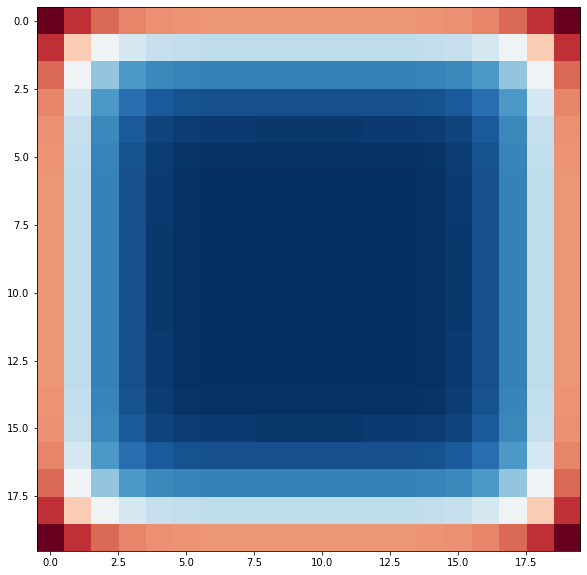

In [5]:
import matplotlib.animation as animation

from IPython.display import HTML

# setter opp figuren
fig, ax = plt.subplots(figsize=(15,10))

ims = []
for i in range(20):
    # fargebilde etter 100*i tidssteg
    im = ax.imshow(-np.reshape(u[100*i,:],(m,n)),cmap='RdBu', animated=True)
    if i == 0:
        # fargebilde ved initialtid
        ax.imshow(-np.reshape(u[0,:],(m,n)),cmap='RdBu')  # initialbilde
    ims.append([im])

# lag animasjonen
ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,
                                repeat_delay=1000)

HTML(ani.to_jshtml())

index = 0
while index < 100000:
    if u[index, 210] >= 60:
        print(u[index])
        break
    index = index + 1

print(u[:,210])